# Iterative Method

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import rel_entr

In [2]:
f = 0.1
X = [0, 1, 2]
#G = np.matrix([[1-2*f, f, f], [f, 1-2*f, f], [f, f, 1-2*f]])
G = np.matrix([[1-f, f, 0], [0, 1-f, f], [f, 0, 1-f]])

In [3]:
def iterator(p):
  pp = np.array(G@p)[0]
  pow = np.array([[pp[i]**G[i,j] for j in X] for i in X])
  g1 = np.prod(pow, axis=0)
  lam = np.log(np.dot(np.exp(-fx), g1))
  p1 = np.exp(-lam - fx)*g1
  return p1

In [39]:
def fixed_point(fx):
  p0 = np.random.rand(3)
  p0 = p0/np.sum(p0)
  epsilon = 0.00000001
  while True:
    pp = np.array(G@p0)[0]
    pow = np.array([[pp[i]**G[i,j] for j in X] for i in X])
    g1 = np.prod(pow, axis=0)
    lam = np.log(np.dot(np.exp(-fx), 1/g1))
    p1 = np.exp(-lam - fx)*1/g1
    if np.sum(np.abs(p1-p0)) < epsilon:
      break
    p0 = p1
  return p1
    #print(p0)

In [40]:
def plot_simplex(points, point):
    # Coordinates for equilateral triangle vertices
    corners = np.array([
        [0, 0],                        # vertex 1
        [1, 0],                        # vertex 2
        [0.5, np.sqrt(3)/2]             # vertex 3
    ])

    # Map 3D simplex points to 2D triangle coordinates
    mapped_points = points @ corners
    mapped_point = point @ corners

    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(mapped_points[:,0], mapped_points[:,1], s=18, color='blue', alpha=1)
    ax.scatter(mapped_point[0], mapped_point[1], s=18, color='red', alpha=1)
    # Draw triangle
    triangle = np.vstack([corners, corners[0]])
    ax.plot(triangle[:,0], triangle[:,1], 'k-')

    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

In [41]:
probs = []
#fx = np.random.rand(3)
fx = np.array([0.47105868, 0.09356638, 0.21129773])
q0 = np.array([0.45952223, 0.33072466, 0.20975311])
#q0 = np.random.rand(3)
q0 = q0/np.sum(q0)
MC = []
residual = []
for k in 2**np.arange(10):
  fxk = k*fx
  #print(fxk)
  #print(fixed_point(fx))
  p0 = fixed_point(fxk)
  probs.append(p0)
  p1 = np.array(G@p0)[0]
  residual.append(np.dot(p0, fxk) + np.dot(p1, np.log(p1)) - np.dot(p0, np.log(p0)))
  MC.append(np.sum(rel_entr(q0, p0))-np.sum(rel_entr(np.array(G@q0), np.array(G@p0))))
print(fx, q0)

[0.47105868 0.09356638 0.21129773] [0.45952223 0.33072466 0.20975311]


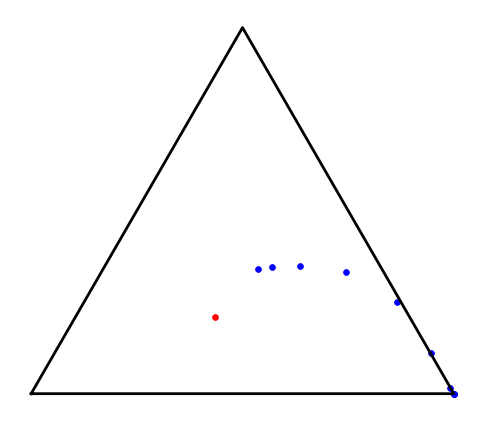

In [42]:
plot_simplex(np.array(probs), q0)

In [43]:
probs

[array([0.29343152, 0.3653507 , 0.34121778]),
 array([0.25584602, 0.39755236, 0.34660162]),
 array([0.18880573, 0.46115667, 0.3500376 ]),
 array([0.09023303, 0.57757972, 0.33218725]),
 array([0.01067711, 0.73990729, 0.2494156 ]),
 array([3.65402573e-05, 8.90164366e-01, 1.09799094e-01]),
 array([2.76518802e-10, 9.83382487e-01, 1.66175127e-02]),
 array([1.34296350e-20, 9.99680045e-01, 3.19954980e-04]),
 array([3.06912947e-41, 9.99999887e-01, 1.12753855e-07]),
 array([5.91696227e-82, 9.99999998e-01, 1.78997864e-09])]

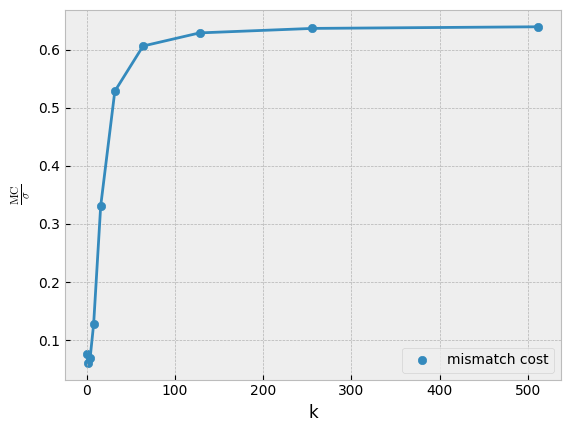

In [44]:
MC = np.array(MC)
residual = np.array(residual)

plt.style.use('bmh')
plt.scatter(2**np.arange(10), MC/(MC+residual), label = 'mismatch cost')
plt.plot(2**np.arange(10), MC/(MC+residual))
plt.xlabel('k')
plt.ylabel(r'$\frac{\mathrm{MC}}{\sigma}$')
#plt.scatter(2**np.arange(10), residual, label = 'residual')
#plt.plot(2**np.arange(10), residual)

plt.legend()
plt.savefig("my_plot.pdf")
plt.show()

# Simulated Annealing

In [ ]:
import numpy as np

def obtain_q0(G, max_iters=500000, T0=1.0, alpha=0.99999, s0=0.99):
    """
    Simulated annealing to minimize:
        C(q) = <fx>_q - S(q) + S(Gq)
    where q is a probability distribution vector.

    Parameters:
        G : np.ndarray
            Matrix of shape (N, M)
        max_iters : int
            Maximum number of iterations
        T0 : float
            Initial temperature
        alpha : float
            Cooling rate
        s0 : float
            Initial mixing parameter

    Returns:
        r0 : float
            Best objective value found
        qx : np.ndarray
            Corresponding probability vector
    """

    M = G.shape[1]
    q = np.random.rand(M)
    q = q / np.sum(q)
    qx = q.copy()

    fx = np.ones(M)

    def entropy(p):
        p = np.clip(p, 1e-12, 1.0)  # Avoid log(0)
        return -np.sum(p * np.log(p))

    def objective(q):
        Gq = G.T @ q
        return entropy(Gq)- entropy(q) + np.dot(fx, q)

    r0 = objective(q)
    T = T0
    s = s0

    for _ in range(max_iters):
        r = np.random.rand(M)
        r = r / np.sum(r)
        q_new = (1 - s) * r + s * q
        q_new = q_new / np.sum(q_new)

        r_new = objective(q_new)

        if (r_new < r0) or (np.random.rand() < np.exp(-(r_new - r0) / T)):
            q = q_new
            qx = q.copy()
            r0 = r_new

        T *= alpha
        s = max(0.9 * s, 0.1)

    return r0, qx
